# 06 — GeoAI compatibility: JupyterLite vs full GeoAI

**[🚀 Launch this notebook live](https://jltobias.github.io/JupyterLite-GeoLibre-GeoAI/lite/lab/index.html?path=06_geoai_compatibility.ipynb)**

The purpose of this chapter is to make the execution boundary explicit instead of hiding it.

`geoai-py` is a comprehensive package for imagery search/download, dataset preparation, training, segmentation, classification, object detection, change detection, visualization, and QGIS integration. Its current dependency list includes **PyTorch, TorchGeo, Transformers, rasterio, OpenCV, scikit-image, and scikit-learn**.

JupyterLite/Pyodide provides many geospatial/scientific packages—including GeoPandas, rasterio, H3, scikit-learn and scikit-image—but does not currently provide PyTorch in its standard package set. Therefore the deep-learning parts of `geoai-py` are not treated as a JupyterLite dependency in this repository.

There is a second boundary: upstream `geolibre.Map` starts a localhost HTTP server for its bundled application. Browser WebAssembly cannot bind that socket, so the live labs use the small `geolibre_lite.LiteMap` adapter. It preserves GeoLibre project/layer builders and uses the upstream hosted viewer/embed bridge instead.

> **JupyterLite compatibility:** this notebook uses `geolibre_lite.LiteMap`, which builds native GeoLibre project/layer definitions and displays them through GeoLibre's hosted `?embed=1` viewer. It deliberately avoids `geolibre.Map`, whose localhost HTTP server cannot bind a socket inside Pyodide/WebAssembly.


## See the connections

![One workflow across three runtimes: Browser: Small arrays, maps and lightweight models; GeoLibre: Hosted viewer renders cloud GIS sources; Server: Astra API credentials stay outside the browser; GPU: Full GeoAI handles large model inference](assets/06_mindmap.svg)

In [1]:
import sys, importlib.util

packages = ["geopandas", "rasterio", "h3", "sklearn", "skimage", "torch"]
availability = {name: importlib.util.find_spec(name) is not None for name in packages}

print("Python platform:", sys.platform)
availability


Python platform: win32


{'geopandas': True,
 'rasterio': True,
 'h3': True,
 'sklearn': True,
 'skimage': False,
 'torch': False}

## Browser-native pattern

Use JupyterLite for:

- cloud-native discovery and small data downloads;
- GeoJSON, COG, PMTiles and GeoParquet exploration;
- spatial joins and feature engineering;
- H3 indexing;
- lightweight raster processing;
- scikit-learn clustering/classification/anomaly detection;
- interactive GeoLibre maps through the browser-safe embed bridge;
- teaching, reproducible demos, and shareable browser labs.

Use full `geoai-py` on CPython/GPU infrastructure for:

- PyTorch model training/inference;
- foundation-model or Transformer workflows;
- large segmentation/detection jobs;
- GPU acceleration;
- native dependencies not compiled for WebAssembly;
- production-scale data preparation.

Use upstream `geolibre.Map` directly in regular Jupyter/JupyterLab/VS Code environments where a kernel-side localhost server or Jupyter Server proxy is available.


In [2]:
import sys
if sys.platform == "emscripten":
    import micropip
    await micropip.install("geolibre==3.0.0")
from geolibre_lite import LiteMap as Map


In [3]:
m = Map(center=(-100, 38), zoom=3, height="560px")
m.add_cog(
    "https://data.source.coop/giswqs/opengeos/nlcd_2021_land_cover_30m.tif",
    name="NLCD 2021 example COG",
)
m


## Full GeoAI continuation

Run the same conceptual workflow in a normal Python 3.12+ environment:

```bash
python -m venv .venv
source .venv/bin/activate   # Windows: .venv\Scripts\activate
python -m pip install -U pip
pip install geoai-py geolibre
```

Then follow the official GeoAI tutorials at https://opengeoai.org/ and the book at https://book.opengeoai.org/.

A useful repository evolution would be to add a second deployment target (Binder, JupyterHub, Codespaces, or a GPU notebook) whose links sit beside each JupyterLite link. The JupyterLite notebook remains the instant browser preview; the full runtime handles deep learning.

## Citations

- GeoAI: Wu, Q. (2026), *Journal of Open Source Software* 11(118), 9605. https://doi.org/10.21105/joss.09605
- GeoAI docs: https://opengeoai.org/
- GeoLibre: https://geolibre.app/
- Pyodide package list: https://pyodide.org/en/stable/usage/packages-in-pyodide.html
- NLCD demo COG is mirrored by the Open Geospatial Solutions Source Cooperative product; source-specific NLCD attribution should be retained if this example is extended to analytical results.


In [4]:
from IPython.display import display
import sys
if sys.platform == "emscripten":
    from pyodide import loadPackage
    await loadPackage("matplotlib")

## Visual runtime decision matrix

This diagram describes the architecture used in this repository, not a benchmark or a promise about every environment. A browser can display the results of a server computation without running that model locally.

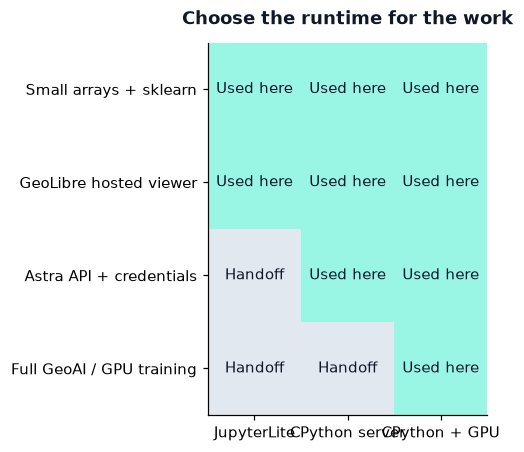

In [5]:
from cognition import style_plots
import matplotlib.pyplot as plt
import numpy as np
style_plots()
tasks = ["Small arrays + sklearn", "GeoLibre hosted viewer", "Astra API + credentials", "Full GeoAI / GPU training"]
matrix = np.array([[1,1,1], [1,1,1], [0,1,1], [0,0,1]])
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
ax.imshow(matrix, cmap=__import__('matplotlib').colors.ListedColormap(["#e2e8f0", "#99f6e4"]), vmin=0, vmax=1)
ax.set_xticks(range(3), ["JupyterLite", "CPython server", "CPython + GPU"])
ax.set_yticks(range(4), tasks)
for r in range(4):
    for c in range(3):
        ax.text(c,r,"Used here" if matrix[r,c] else "Handoff",ha="center",va="center")
ax.set_title("Choose the runtime for the work")
plt.show()

**Follow the handoff:** browser features → GeoJSON/JSON/PNG export → full GeoAI inference or Astra request → validated result → GeoLibre. Labs 12–15 implement that bridge without storing API keys in JupyterLite.